In [1]:
from agentlab.experiments.exp_utils import RESULTS_DIR
from agentlab.analyze import inspect_results
from agentlab.experiments.study import get_most_recent_study

import pandas as pd

RESULTS_DIR

PosixPath('/home/nlp/users/azambrano/agentlab_results')

In [2]:
import glob

experiments = glob.glob(str(RESULTS_DIR)+"/*")
dfs= []
for a in experiments:
    study_name = a.split("/")[-1]
    if study_name.endswith(".zip") or study_name.endswith("archive"):
        continue
    print("Study Name:",study_name)
    result_dir= get_most_recent_study(RESULTS_DIR, contains=study_name)
    result_df = inspect_results.load_result_df(result_dir)
    if result_df is None:
        print("No result found for study:", study_name)
        continue
    dfs.append(result_df)


Study Name: 2025-04-19_15-40-16_generic-on-webarena-train_generic


Searching experiments directories.: 0it [00:00, ?it/s]


No result found for study: 2025-04-19_15-40-16_generic-on-webarena-train_generic
Study Name: 2025-04-21_11-31-46_generic-on-webarena-train_generic


Loading results:   0%|          | 0/431 [00:00<?, ?it/s]/home/nlp/users/azambrano/multi-web-agent/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading results: 100%|██████████| 431/431 [00:02<00:00, 158.63it/s]


Study Name: 2025-05-03_23-37-04_generic-on-webarena-train_generic


...

Loading results: 100%|██████████| 431/431 [00:00<00:00, 3114.50it/s]


Study Name: 2025-05-02_22-03-33_generic-on-webarena-train_generic


Loading results: 100%|██████████| 431/431 [00:00<00:00, 3112.56it/s]


Study Name: 2025-05-03_09-25-03_generic-on-webarena-train_generic


Loading results: 100%|██████████| 431/431 [00:00<00:00, 3042.22it/s]


In [3]:
reward_df = dfs[0]["cum_reward"].reset_index().set_index("env.task_name").copy().rename(columns={"cum_reward": "cum_reward_" + "0"})
for i,df in enumerate(dfs[1:]):
    reward_df_iter= df["cum_reward"].reset_index().set_index("env.task_name").copy().rename(columns={"cum_reward": "cum_reward_" + str(i+1)}) 
    reward_df = pd.merge(reward_df, reward_df_iter, on=["env.task_name","agent.agent_name","env.benchmark"])

In [4]:
reward_df

,agent.agent_name,env.benchmark,cum_reward_0,cum_reward_1,cum_reward_2,cum_reward_3,cum_reward_4,cum_reward_5,cum_reward_6,cum_reward_7,cum_reward_8,cum_reward_9
env.task_name,,,,,,,,,,,,
webarena.0,GenericAgent-gpt-4o-mini-2024-07-18,webarena,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
webarena.101,GenericAgent-gpt-4o-mini-2024-07-18,webarena,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
webarena.102,GenericAgent-gpt-4o-mini-2024-07-18,webarena,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
webarena.103,GenericAgent-gpt-4o-mini-2024-07-18,webarena,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
webarena.105,GenericAgent-gpt-4o-mini-2024-07-18,webarena,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
webarena.91,GenericAgent-gpt-4o-mini-2024-07-18,webarena,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
webarena.92,GenericAgent-gpt-4o-mini-2024-07-18,webarena,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
webarena.93,GenericAgent-gpt-4o-mini-2024-07-18,webarena,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [5]:
reward_df['number_success'] = reward_df['cum_reward_0']+reward_df['cum_reward_1']+reward_df['cum_reward_2']+reward_df['cum_reward_3']+reward_df['cum_reward_4']

In [6]:
hard=reward_df[reward_df['number_success'] ==0]
medium=reward_df[reward_df['number_success'].between(2,4)]
easy = reward_df[reward_df['number_success'] == 1]

Number of Hard tasks: 305
Number of Medium tasks: 61
Number of Easy tasks: 27


<BarContainer object of 3 artists>

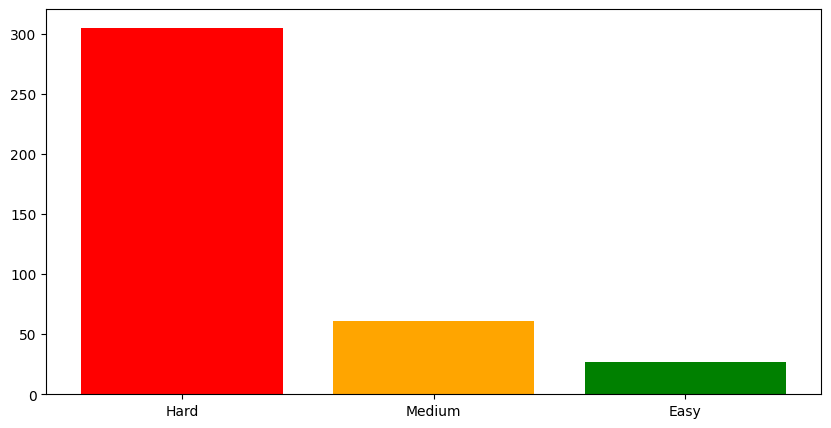

In [7]:
import matplotlib.pyplot as plt
len_hard = len(hard)
len_medium = len(medium)
len_easy = len(easy)

print("Number of Hard tasks:", len_hard)
print("Number of Medium tasks:", len_medium)
print("Number of Easy tasks:", len_easy)

plt.figure(figsize=(10, 5))
plt.bar(['Hard', 'Medium', 'Easy'], [len_hard, len_medium, len_easy], color=['red', 'orange', 'green'])


In [8]:
import json
from random import sample

hard_ids= [ task.split('.')[1] for task in hard.index]

val_split = sample(hard_ids,int(len(hard_ids)*0.10))

with open("../data/val_split.json", "w") as f:
    json.dump(val_split, f)
with open("../data/hard_tasks.json", "w") as f:
    json.dump(hard_ids, f)
medium_ids= [ task.split('.')[1] for task in medium.index]
with open("../data/medium_tasks.json", "w") as f:
    json.dump(medium_ids, f)
easy_ids= [ task.split('.')[1] for task in easy.index]
with open("../data/easy_tasks.json", "w") as f:
    json.dump(easy_ids, f)

